In [1]:
# This allows us to import from all folders one level up from notebooks folder - run 1 time
import sys
from pathlib import Path

print('All paths pre-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")
print('-'*100)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
print('All paths post-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")


All paths pre-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
----------------------------------------------------------------------------------------------------
All paths post-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
5: /Users/irabandutta/Developer/2026-08-llm-from-scratch


# Imports

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from src.model.llm_config import LLMConfig
from src.model.llm import LLM

# Define Model

In [3]:
ctx_len = 32
d_model = 64

config = LLMConfig(
    vocab_size=50257,
    ctx_len=ctx_len,
    d_model=d_model, 
    n_layer=2,
    ff_ratio=4,
    dropout=0.0,
    eps=1e-5,
    bias=False,
    position_embedding='sinusoidal',
    rotary_embedding=False,
    attention='mha',
    normalization='layernorm',
    n_heads=4, 
    n_groups=None,
    use_flash=False, 
    attn_debug=False
)
print(config)
print('-'*50)

# Detect and resolve device
device = 'cpu'
if torch.cuda.is_available():
    device='cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device='mps'

print("Device found:", device)
print('-'*50)


# Instantiate model
model = LLM(config)
model = model.to(device)
print(f"Model moved to {device}")
print('-'*50)

# Total params
total_params = model._get_num_params()

LLMConfig(vocab_size=50257, ctx_len=32, d_model=64, n_layer=2, ff_ratio=4, dropout=0.0, eps=1e-05, bias=False, position_embedding='sinusoidal', rotary_embedding=False, attention='mha', normalization='layernorm', n_heads=4, n_groups=None, use_flash=False, attn_debug=False)
--------------------------------------------------
Device found: mps
--------------------------------------------------
Weight Tying Done: B/W initial Embedding Layer and final Linear Layer before Softmax!
Model initialized, number of parameters: 3.32M
Model moved to mps
--------------------------------------------------


In [4]:
model

LLM(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 64)
    (wpe): SinusoidalPositionalEncoding()
    (drp): Dropout(p=0.0, inplace=False)
    (dec): ModuleList(
      (0-1): 2 x Decoder(
        (ln_attn): LayerNorm()
        (attn): MultiHeadAttention(
          (proj_qkv): Linear(in_features=64, out_features=192, bias=True)
          (proj_out): Linear(in_features=64, out_features=64, bias=True)
          (dropout_attn): Dropout(p=0.0, inplace=False)
          (dropout_out): Dropout(p=0.0, inplace=False)
        )
        (ln_mlp): LayerNorm()
        (mlp): MLP(
          (proj_in): Linear(in_features=64, out_features=256, bias=False)
          (gelu): GELU(approximate='tanh')
          (proj_out): Linear(in_features=256, out_features=64, bias=False)
        )
      )
    )
    (ln_final): LayerNorm()
  )
  (lm_head): Linear(in_features=64, out_features=50257, bias=False)
)

# nn.Module

In [5]:
# state_dict()
print(f"Total params: {total_params/1e6:.2f}M")
print('-'*100)
print(f"{'Param':45s} {'Shape':15s} {'Contribution':10s}")
for k,v in model.state_dict().items():
    print(f"{k:45s} {str(tuple(v.shape)):15s} {(100.0*v.nelement()/total_params):10.2f}%")
print('-'*100)

Total params: 3.32M
----------------------------------------------------------------------------------------------------
Param                                         Shape           Contribution
transformer.wte.weight                        (50257, 64)          97.01%
transformer.dec.0.ln_attn.gamma               (64,)                 0.00%
transformer.dec.0.attn.proj_qkv.weight        (192, 64)             0.37%
transformer.dec.0.attn.proj_qkv.bias          (192,)                0.01%
transformer.dec.0.attn.proj_out.weight        (64, 64)              0.12%
transformer.dec.0.attn.proj_out.bias          (64,)                 0.00%
transformer.dec.0.ln_mlp.gamma                (64,)                 0.00%
transformer.dec.0.mlp.proj_in.weight          (256, 64)             0.49%
transformer.dec.0.mlp.proj_out.weight         (64, 256)             0.49%
transformer.dec.1.ln_attn.gamma               (64,)                 0.00%
transformer.dec.1.attn.proj_qkv.weight        (192, 64)         

In [6]:
# named_parameters()
for tup in model.named_parameters():
    print(f"{tup[0]:45s} | {str(tuple(tup[1].shape)):10s}")

transformer.wte.weight                        | (50257, 64)
transformer.dec.0.ln_attn.gamma               | (64,)     
transformer.dec.0.attn.proj_qkv.weight        | (192, 64) 
transformer.dec.0.attn.proj_qkv.bias          | (192,)    
transformer.dec.0.attn.proj_out.weight        | (64, 64)  
transformer.dec.0.attn.proj_out.bias          | (64,)     
transformer.dec.0.ln_mlp.gamma                | (64,)     
transformer.dec.0.mlp.proj_in.weight          | (256, 64) 
transformer.dec.0.mlp.proj_out.weight         | (64, 256) 
transformer.dec.1.ln_attn.gamma               | (64,)     
transformer.dec.1.attn.proj_qkv.weight        | (192, 64) 
transformer.dec.1.attn.proj_qkv.bias          | (192,)    
transformer.dec.1.attn.proj_out.weight        | (64, 64)  
transformer.dec.1.attn.proj_out.bias          | (64,)     
transformer.dec.1.ln_mlp.gamma                | (64,)     
transformer.dec.1.mlp.proj_in.weight          | (256, 64) 
transformer.dec.1.mlp.proj_out.weight         | (64, 25

In [7]:
# parameters()
print([p.nelement() for p in model.parameters()])

[3216448, 64, 12288, 192, 4096, 64, 64, 16384, 16384, 64, 12288, 192, 4096, 64, 64, 16384, 16384, 64]


In [8]:
# model.eval(), model.train(), model.training
print(model.training)
model.eval()
print(model.training)
model.train()
print(model.training)

True
False
True


In [9]:
# ModuleDict works as a normal Dict
for k, v in model.transformer.items():
    print(k, type(v))

wte <class 'torch.nn.modules.sparse.Embedding'>
wpe <class 'src.model.position_embedding.SinusoidalPositionalEncoding'>
drp <class 'torch.nn.modules.dropout.Dropout'>
dec <class 'torch.nn.modules.container.ModuleList'>
ln_final <class 'src.model.normalization.LayerNorm'>


In [10]:
# ModuleList works as a normal list
for dec_i in model.transformer.dec:
    print(type(dec_i).__name__, type(dec_i))

Decoder <class 'src.model.layers.Decoder'>
Decoder <class 'src.model.layers.Decoder'>


In [11]:
# 📌 PyTorch Cheat Sheet: modules() vs. children()
# ----------------------------------------------------
# 1. DEPTH: .children() is shallow (looks ONLY at immediate, top-level submodules).
# 2. RECURSION: .modules() is deep (recursively visits ALL nested layers and sub-blocks).
# 3. ROOT MODULE: .modules() includes the main/parent model itself; .children() does not.
# 4. USE CASE (.children()): Ideal for freezing top-level layers or swapping specific blocks.
# 5. USE CASE (.modules()): Ideal for global tasks like model-wide weight initialization.

# ======== modules() ========
# list(model.modules())

# ======== children() ========
# list(model.children())

In [12]:
print(list(model.children()))
print('-'*100)

[ModuleDict(
  (wte): Embedding(50257, 64)
  (wpe): SinusoidalPositionalEncoding()
  (drp): Dropout(p=0.0, inplace=False)
  (dec): ModuleList(
    (0-1): 2 x Decoder(
      (ln_attn): LayerNorm()
      (attn): MultiHeadAttention(
        (proj_qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj_out): Linear(in_features=64, out_features=64, bias=True)
        (dropout_attn): Dropout(p=0.0, inplace=False)
        (dropout_out): Dropout(p=0.0, inplace=False)
      )
      (ln_mlp): LayerNorm()
      (mlp): MLP(
        (proj_in): Linear(in_features=64, out_features=256, bias=False)
        (gelu): GELU(approximate='tanh')
        (proj_out): Linear(in_features=256, out_features=64, bias=False)
      )
    )
  )
  (ln_final): LayerNorm()
), Linear(in_features=64, out_features=50257, bias=False)]
----------------------------------------------------------------------------------------------------


In [13]:
print(list(model.modules()))
print('-'*100)

[LLM(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 64)
    (wpe): SinusoidalPositionalEncoding()
    (drp): Dropout(p=0.0, inplace=False)
    (dec): ModuleList(
      (0-1): 2 x Decoder(
        (ln_attn): LayerNorm()
        (attn): MultiHeadAttention(
          (proj_qkv): Linear(in_features=64, out_features=192, bias=True)
          (proj_out): Linear(in_features=64, out_features=64, bias=True)
          (dropout_attn): Dropout(p=0.0, inplace=False)
          (dropout_out): Dropout(p=0.0, inplace=False)
        )
        (ln_mlp): LayerNorm()
        (mlp): MLP(
          (proj_in): Linear(in_features=64, out_features=256, bias=False)
          (gelu): GELU(approximate='tanh')
          (proj_out): Linear(in_features=256, out_features=64, bias=False)
        )
      )
    )
    (ln_final): LayerNorm()
  )
  (lm_head): Linear(in_features=64, out_features=50257, bias=False)
), ModuleDict(
  (wte): Embedding(50257, 64)
  (wpe): SinusoidalPositionalEncoding()
  (drp): Dropou

In [14]:
# def fn(module):
#     pass

# Recursively applies fn to sub-modules of model
# ------------------------------------------------
# model.apply(fn)

# def apply(self, fn):
#     # First call fn on the object which is calling apply(), ie self
#     fn(self)
#     # Then recursively call fn on all the sub modules of self
#     for child in model.children():
#         child.apply(fn)

In [15]:
print(isinstance(list(model.children())[1], nn.Linear))

True


# Residual path init Scaling

10.0342003364563 1.4116895505189895
--------------------------------------------------


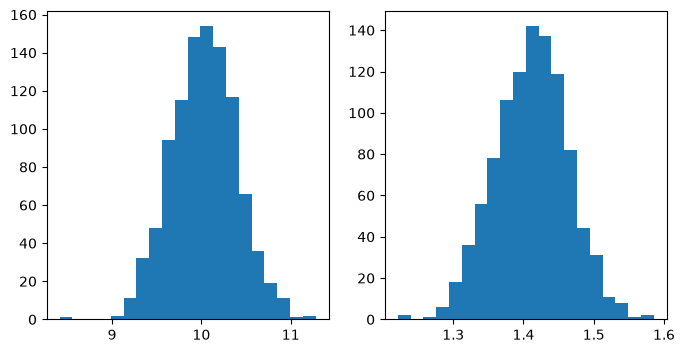

In [16]:
std1, std2 = [], []
exp = 1000
g = torch.Generator().manual_seed(42)

for _ in range(exp):
    # x1 = torch.zeros(384)
    # x2 = torch.zeros(384)
    x1 = torch.randn(384)
    x2 = torch.randn(384)
    # print(x1.std(), x2.std())

    layers = 100
    for _ in range(layers):
        x1 += torch.randn(x1.shape[0])
        x2 += (1/(layers**0.5)) * torch.randn(x2.shape[0])
    # print(x1.std(), x2.std())
    std1.append(x1.std().item())
    std2.append(x2.std().item()) 

print(np.mean(std1), np.mean(std2))
print('-'*50)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(std1, bins=20)
plt.subplot(1, 2, 2)
plt.hist(std2, bins=20)
plt.show()

In [17]:
# modules having the attribute 'RESIDUAL_PATH_SCALE_INIT'
for module in model.modules():
    if hasattr(module, 'RESIDUAL_PATH_SCALE_INIT'):
        print(module)

Linear(in_features=64, out_features=64, bias=True)
Linear(in_features=256, out_features=64, bias=False)
Linear(in_features=64, out_features=64, bias=True)
Linear(in_features=256, out_features=64, bias=False)


# Grad Clip using torch.nn.utils.clip_grad_norm_()

In [18]:
x = torch.randn(100, 10)
y = torch.randint(0, 2, (100,))


model_dummy = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)
total_params = sum(p.nelement() for p in model_dummy.parameters())
print(total_params)
print('-'*50)

optimizer = torch.optim.AdamW(model_dummy.parameters(), 1e-2) 

for i in range(1):
    optimizer.zero_grad()
    y_pred = model_dummy(x)
    loss = torch.nn.functional.binary_cross_entropy(y_pred, y.unsqueeze(dim=1).float())
    loss.backward()
    optimizer.step()
    print(f"Step:{i}, Loss: {loss}")
print('-'*50)

grad_norm_hand = sum(torch.linalg.norm(p.grad)**2 for p in model_dummy.parameters())**0.5
print('Hand compute norm:', grad_norm_hand)
grad_norm_util = torch.nn.utils.clip_grad_norm_(model_dummy.parameters(), max_norm=1.0)
print('Util compute norm:', grad_norm_util)

assert grad_norm_hand==grad_norm_util, (
    f'Norms match failed'
)

4577
--------------------------------------------------
Step:0, Loss: 0.6914176344871521
--------------------------------------------------
Hand compute norm: tensor(0.0431)
Util compute norm: tensor(0.0431)


# LR Scheduler

In [19]:
hasattr(optimizer, 'param_groups')

True

In [20]:
# just 1 element in the list
optimizer.param_groups

[{'params': [Parameter containing:
   tensor([[ 0.0139,  0.2465, -0.0858,  0.0207,  0.2664,  0.1016,  0.0065, -0.0468,
             0.2761,  0.2477],
           [ 0.2106, -0.0199,  0.1484, -0.1645,  0.2546,  0.2654,  0.2173,  0.0226,
            -0.2855, -0.0599],
           [ 0.2656,  0.2529,  0.0107,  0.2138, -0.3224, -0.0285,  0.1614,  0.2232,
            -0.0976,  0.2321],
           [ 0.2718, -0.1603, -0.0981, -0.2331, -0.2700, -0.0901, -0.0777,  0.2066,
             0.2424,  0.3100],
           [ 0.0864,  0.1542, -0.2505,  0.0422,  0.2516,  0.0760, -0.1615, -0.1595,
            -0.0102, -0.0784],
           [ 0.0036, -0.2472, -0.0008, -0.2757, -0.0165, -0.3131,  0.0491, -0.0773,
             0.0800,  0.0945],
           [ 0.0008, -0.0986,  0.1777, -0.0169, -0.1602,  0.0383, -0.0152,  0.2715,
            -0.1194,  0.1188],
           [-0.1706, -0.1810,  0.0782,  0.0241,  0.2504, -0.0522, -0.0571, -0.0858,
             0.1375, -0.0480],
           [ 0.2920, -0.3002, -0.0062,  0.224

In [21]:
# Index into learning rate
optimizer.param_groups[0]['lr']

0.01

[1.   0.99 0.98 0.97 0.96 0.95 0.94 0.93 0.92 0.91 0.9  0.89 0.88 0.87
 0.86 0.85 0.84 0.83 0.82 0.81 0.8  0.79 0.78 0.77 0.76 0.75 0.74 0.73
 0.72 0.71 0.7  0.69 0.68 0.67 0.66 0.65 0.64 0.63 0.62 0.61 0.6  0.59
 0.58 0.57 0.56 0.55 0.54 0.53 0.52 0.51 0.5  0.49 0.48 0.47 0.46 0.45
 0.44 0.43 0.42 0.41 0.4  0.39 0.38 0.37 0.36 0.35 0.34 0.33 0.32 0.31
 0.3  0.29 0.28 0.27 0.26 0.25 0.24 0.23 0.22 0.21 0.2  0.19 0.18 0.17
 0.16 0.15 0.14 0.13 0.12 0.11 0.1  0.09 0.08 0.07 0.06 0.05 0.04 0.03
 0.02 0.01]
----------------------------------------------------------------------------------------------------


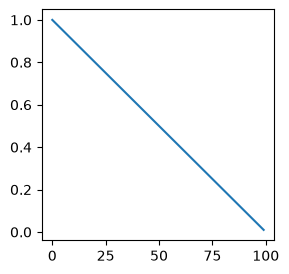

In [22]:
# LR Linear Decay
T=100
lr1 = 1 - (np.arange(0, T))/T
print(lr1)
print('-'*100)
plt.figure(figsize=(3, 3))
plt.plot(range(len(lr1)), lr1)
plt.show()

[1.00000000e+00 9.99753280e-01 9.99013364e-01 9.97780982e-01
 9.96057351e-01 9.93844170e-01 9.91143625e-01 9.87958381e-01
 9.84291581e-01 9.80146843e-01 9.75528258e-01 9.70440384e-01
 9.64888243e-01 9.58877313e-01 9.52413526e-01 9.45503262e-01
 9.38153340e-01 9.30371014e-01 9.22163963e-01 9.13540287e-01
 9.04508497e-01 8.95077506e-01 8.85256621e-01 8.75055535e-01
 8.64484314e-01 8.53553391e-01 8.42273553e-01 8.30655933e-01
 8.18711995e-01 8.06453527e-01 7.93892626e-01 7.81041689e-01
 7.67913397e-01 7.54520708e-01 7.40876837e-01 7.26995250e-01
 7.12889646e-01 6.98573945e-01 6.84062276e-01 6.69368960e-01
 6.54508497e-01 6.39495553e-01 6.24344944e-01 6.09071621e-01
 5.93690657e-01 5.78217233e-01 5.62666617e-01 5.47054157e-01
 5.31395260e-01 5.15705380e-01 5.00000000e-01 4.84294620e-01
 4.68604740e-01 4.52945843e-01 4.37333383e-01 4.21782767e-01
 4.06309343e-01 3.90928379e-01 3.75655056e-01 3.60504447e-01
 3.45491503e-01 3.30631040e-01 3.15937724e-01 3.01426055e-01
 2.87110354e-01 2.730047

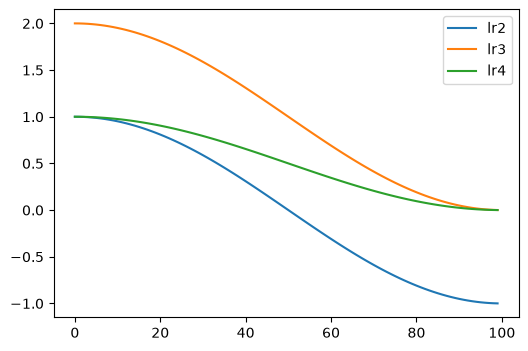

In [23]:
lr2 = np.cos((1*np.pi/T)*np.arange(T))
lr3 = 1+lr2
lr4 = 0.5*lr3
print(lr4)
print('-'*100)
plt.figure(figsize=(6, 4))
plt.plot(range(len(lr2)), lr2, label='lr2')
plt.plot(range(len(lr3)), lr3, label='lr3')
plt.plot(range(len(lr4)), lr4, label='lr4')
plt.legend()
plt.show()

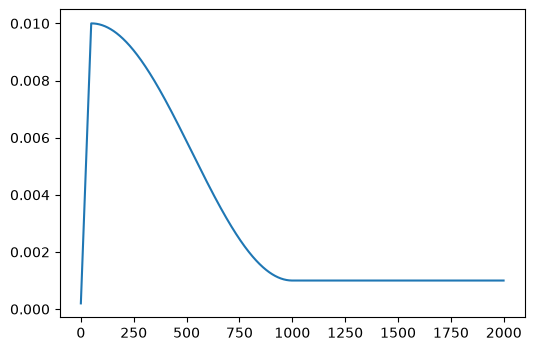

In [24]:
def get_lr(init_lr, final_lr, max_step, warmup_steps, curr_step):
    
    assert final_lr>0 and 0<(final_lr/init_lr)<1, (
        f"LRs should be > 0. Also final LR should be less than inital LR, got values: initial LR: {init_lr} & final LR: {final_lr}"
    )
    warmup_steps_resolved = min(warmup_steps, int(0.15*max_step))
    if curr_step<warmup_steps:
        # Linear Warmup
        return init_lr*((curr_step+1)/warmup_steps)
    elif curr_step>max_step:
        # Keep training with final_lr
        return final_lr

    # Cosine Decay (From warmup_step to max_step)
    cosine_curve = 0.5*(np.cos((np.pi/(max_step-warmup_steps))*(curr_step-warmup_steps)) + 1)
    return (init_lr-final_lr)*cosine_curve + final_lr


init_lr = 1e-2
final_lr = 0.1*init_lr
T = 1000
warmup_steps = 50
steps = np.arange(0, 2000)
lr_scheduler = list(map(lambda x: get_lr(init_lr, final_lr, T, warmup_steps, x), steps))
plt.figure(figsize=(6, 4))
plt.plot(range(len(lr_scheduler)), lr_scheduler)
plt.show()

# torch.optim - per_parameter options

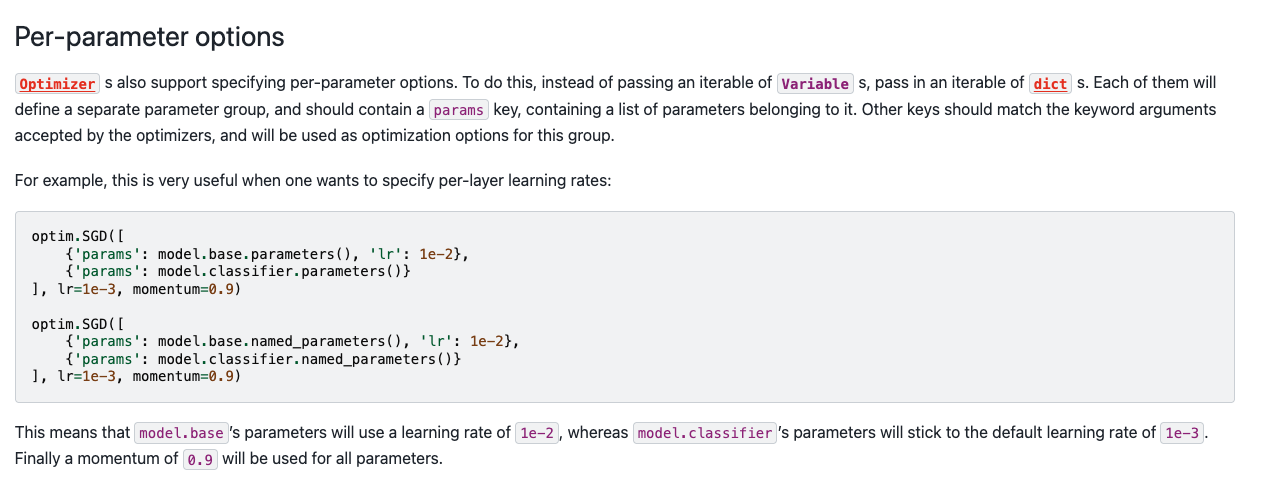

# Fused Adam

In [25]:
# fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
# use_fused = fused_available and device_type == 'cuda'
# extra_args = dict(fused=True) if use_fused else dict()

In [26]:
optimizer.param_groups

[{'params': [Parameter containing:
   tensor([[ 0.0139,  0.2465, -0.0858,  0.0207,  0.2664,  0.1016,  0.0065, -0.0468,
             0.2761,  0.2477],
           [ 0.2106, -0.0199,  0.1484, -0.1645,  0.2546,  0.2654,  0.2173,  0.0226,
            -0.2855, -0.0599],
           [ 0.2656,  0.2529,  0.0107,  0.2138, -0.3224, -0.0285,  0.1614,  0.2232,
            -0.0976,  0.2321],
           [ 0.2718, -0.1603, -0.0981, -0.2331, -0.2700, -0.0901, -0.0777,  0.2066,
             0.2424,  0.3100],
           [ 0.0864,  0.1542, -0.2505,  0.0422,  0.2516,  0.0760, -0.1615, -0.1595,
            -0.0102, -0.0784],
           [ 0.0036, -0.2472, -0.0008, -0.2757, -0.0165, -0.3131,  0.0491, -0.0773,
             0.0800,  0.0945],
           [ 0.0008, -0.0986,  0.1777, -0.0169, -0.1602,  0.0383, -0.0152,  0.2715,
            -0.1194,  0.1188],
           [-0.1706, -0.1810,  0.0782,  0.0241,  0.2504, -0.0522, -0.0571, -0.0858,
             0.1375, -0.0480],
           [ 0.2920, -0.3002, -0.0062,  0.224

In [27]:
print(optimizer.param_groups[0]['fused'])

None


In [28]:
fused_avail = False

for pg in optimizer.param_groups:
    fused_avail = 'fused' in pg.keys() 
    print('fused' in pg.keys())

print(fused_avail)

True
True


In [29]:
optim_test1 = torch.optim.AdamW(model.parameters(), fused=True)
print(optim_test1.param_groups[0]['fused'])

optim_test2 = torch.optim.AdamW(model.parameters())
print(optim_test2.param_groups[0]['fused'])

True
None
